In [ ]:
# =====================================================
# CHOIX DE L'EXPÉRIENCE
# =====================================================

EXPERIMENT = "exp_detect_peak"


In [ ]:
import pickle
import sys
from pathlib import Path

# =====================================================
# CONFIGURATION DU PROJET
# =====================================================

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.analysis.fonction import process_experiment
from src.plot.dashboard import launch_dashboard
from src.utils.config_loader import load_config

# =====================================================
# CHARGEMENT DES RÉSULTATS PRÉCALCULÉS
# =====================================================

results_path = PROJECT_ROOT / "experiments" / EXPERIMENT / "results.pkl"
with results_path.open("rb") as f:
    results = pickle.load(f)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import ipywidgets as widgets
from IPython.display import display, clear_output

# ------------------------------------------------------------
# PARAMÈTRES
# ------------------------------------------------------------

FREQUENCIES = [
    10, 15, 20, 33, 45, 67,
    100, 150, 215, 315, 460, 1000
]

E_MIN = 0.0017
E_MAX = 0.014

FLIGHT_PATH = 1.9
PULSE_WIDTH = 3.5
RF_FACTOR = 145

E_nc=results["fre10"].sigma.ncrystal.x
sigma_nc=results["fre10"].sigma.ncrystal.y
mask = (E_nc > E_MIN) & (E_nc < E_MAX)
E_nc = E_nc[mask]
sigma_nc = sigma_nc[mask]

def delta_E(E_eV, frequency):
    v = 13850 * np.sqrt(E_eV)
    t = FLIGHT_PATH / v
    delta_t = PULSE_WIDTH / (RF_FACTOR * 2 * np.pi * frequency)
    return E_eV * (2 * delta_t / t)

# ------------------------------------------------------------
# STOCKAGE PARAMÈTRES PAR FREQUENCE
# ------------------------------------------------------------

params = {
    f: {"prominence": 5.0, "width": 50}
    for f in FREQUENCIES
}

# ------------------------------------------------------------
# UI : un bloc par fréquence
# ------------------------------------------------------------

outs = {}

ui_blocks = []

def make_block(f):

    prom_slider = widgets.FloatSlider(
        value=params[f]["prominence"],
        min=0.5,
        max=20,
        step=0.1,
        description=f"{f}Hz Prom"
    )

    width_slider = widgets.IntSlider(
        value=params[f]["width"],
        min=1,
        max=100,
        step=1,
        description="Width"
    )

    out = widgets.Output()
    outs[f] = out

    def update(_=None):

        sim = results[f"fre{f}"]

        energy = sim.sigma.tof.x
        sigma = sim.sigma.tof.y

        mask = (energy > E_MIN) & (energy < E_MAX)
        energy = energy[mask]
        sigma = sigma[mask]

        noise = np.std(np.diff(sigma))

        prom = prom_slider.value
        width = width_slider.value

        params[f]["prominence"] = prom
        params[f]["width"] = width

        peaks, _ = find_peaks(
            sigma,
            prominence=prom * noise,
            width=width
        )

        dE = np.array([delta_E(e, f) for e in energy[peaks]])

        with out:
            clear_output(wait=True)

            plt.figure(figsize=(10,8))
            plt.plot(energy, sigma, color="black", alpha=0.8)

            plt.errorbar(
                energy[peaks],
                sigma[peaks],
                xerr=dE,
                fmt="or",
                capsize=3,
                alpha=0.5
            )
            plt.plot(E_nc,sigma_nc,color="blue",alpha=0.2)

            plt.xscale("log")
            plt.title(f"{f} Hz")
            plt.grid(alpha=0.3)
            plt.show()

    prom_slider.observe(update, names="value")
    width_slider.observe(update, names="value")

    update()

    return widgets.VBox([prom_slider, width_slider, out])


for f in FREQUENCIES:
    ui_blocks.append(make_block(f))

# ------------------------------------------------------------
# AFFICHAGE GLOBAL
# ------------------------------------------------------------

display(widgets.VBox(ui_blocks))



In [ ]:
params = {
    10:  {"prominence": 18, "width": 50},
    15:  {"prominence": 11, "width": 50},
    20:  {"prominence": 10, "width":50},
    33:  {"prominence": 10, "width": 50},
    45:  {"prominence": 7.5, "width": 25},
    67:  {"prominence": 6, "width": 10},
    100: {"prominence": 3, "width": 25},
    150: {"prominence": 3, "width": 25},
    215: {"prominence": 3, "width": 25},
    315: {"prominence": 2.5, "width": 25},
    460: {"prominence": 1.5, "width": 25},
    1000: {"prominence": 1.5, "width": 25},
}

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ------------------------------------------------------------
# PARAMÈTRES
# ------------------------------------------------------------

FREQUENCIES = [
    10, 15, 20, 33,
    45, 67, 100, 150,
    215, 315, 460, 1000
]

E_MIN = 0.000
E_MAX = 0.03

FLIGHT_PATH = 1.9
PULSE_WIDTH = 3.5
RF_FACTOR = 145

E_nc=results["fre10"].sigma.ncrystal.x
sigma_nc=results["fre10"].sigma.ncrystal.y
mask = (E_nc > E_MIN) & (E_nc < E_MAX)
E_nc = E_nc[mask]
sigma_nc = sigma_nc[mask]

def delta_E(E_eV, f):
    v = 13850 * np.sqrt(E_eV)
    t = FLIGHT_PATH / v
    dt = PULSE_WIDTH / (RF_FACTOR * 2 * np.pi * f)
    return E_eV * (2 * dt / t)

# ------------------------------------------------------------
# PARAMS (DOIVENT DÉJÀ EXISTER CHEZ TOI)
# ------------------------------------------------------------
# params = {f: {"prominence": ..., "width": ...}, ...}

# ------------------------------------------------------------
# STOCK GLOBAL
# ------------------------------------------------------------

all_E = []
all_f = []
all_dE = []

# ------------------------------------------------------------
# FIGURE GRID
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 4, figsize=(22, 12))
axes = axes.ravel()

# ------------------------------------------------------------
# LOOP
# ------------------------------------------------------------

for i, f in enumerate(FREQUENCIES):

    sim = results[f"fre{f}"]

    energy = sim.sigma.tof.x
    sigma = sim.sigma.tof.y

    mask = (energy > E_MIN) & (energy < E_MAX)
    energy = energy[mask]
    sigma = sigma[mask]

    noise = np.std(np.diff(sigma))

    prom = params[f]["prominence"]
    width = params[f]["width"]

    peaks, _ = find_peaks(
        sigma,
        prominence=prom * noise,
        width=width
    )

    E_peaks = energy[peaks]
    dE = np.array([delta_E(e, f) for e in E_peaks])

    # -------------------------
    # PLOT INDIVIDUEL
    # -------------------------
    ax = axes[i]

    # fond NCrystal (transparent)
    ax.plot(
        E_nc,
        sigma_nc,
        color="blue",
        alpha=0.15,
        lw=2
    )

    # simulation
    ax.plot(
        energy,
        sigma,
        color="black",
        lw=1
    )

    # peaks + error bars
    ax.errorbar(
        E_peaks,
        sigma[peaks],
        xerr=dE,
        fmt="o",
        color="red",
        ecolor="red",
        capsize=3,
        alpha=0.4,
        markersize=4
    )

    ax.set_xscale("log")
    ax.set_title(f"{f} Hz")
    ax.grid(alpha=0.3)

    # -------------------------
    # GLOBAL STORAGE
    # -------------------------
    if len(E_peaks) > 0:
        all_E.append(E_peaks)
        all_f.append(np.full_like(E_peaks, f, dtype=float))
        all_dE.append(dE)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# CARTE GLOBALE
# ------------------------------------------------------------

plt.figure(figsize=(22, 14))

if len(all_E) > 0:

    all_E = np.concatenate(all_E)
    all_f = np.concatenate(all_f)
    all_dE = np.concatenate(all_dE)

    plt.errorbar(
        all_E,
        all_f,
        xerr=all_dE,
        fmt="o",
        color="red",
        ecolor="red",
        alpha=0.6,
        capsize=3,
        markersize=4
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Énergie (eV)")
plt.ylabel("Fréquence (Hz)")
plt.title("Carte globale des pics détectés")

plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
from scipy.signal import find_peaks, peak_widths

# --- ta résolution instrumentale ---
def delta_E(E_eV, f):
    v = 13850 * np.sqrt(E_eV)
    t = FLIGHT_PATH / v
    dt = PULSE_WIDTH / (RF_FACTOR * 2 * np.pi * f)
    return E_eV * (2 * dt / t)


# --- détection + filtrage des pics ---
def detect_bragg_peaks(E_axis, signal, f,
                       height_rel=0.1,
                       prominence=0.05,
                       merge_factor=0.2):

    # 1. détection brute
    peaks, props = find_peaks(signal, height=height_rel*np.max(signal),
                               prominence=prominence*np.max(signal))

    if len(peaks) == 0:
        return np.array([]), np.array([])

    E_peaks = E_axis[peaks]

    # 2. largeur (FWHM en énergie)
    widths = peak_widths(signal, peaks, rel_height=0.5)[0]
    dE_axis = np.mean(np.diff(E_axis))
    FWHM = widths * dE_axis

    # 3. énergie + intensité
    intensities = signal[peaks]

    # 4. tri par intensité (important pour éliminer petits pics)
    order = np.argsort(intensities)[::-1]

    keep = np.ones(len(peaks), dtype=bool)

    for i in order:
        if not keep[i]:
            continue

        Ei = E_peaks[i]
        Wi = FWHM[i]

        # critère physique : résolution détecteur
        res = delta_E(Ei, f)

        # on ignore les pics non résolus ou trop faibles
        for j in range(len(peaks)):
            if i == j or not keep[j]:
                continue

            Ej = E_peaks[j]

            # si pic j est dans la largeur effective du pic i
            if abs(Ej - Ei) < merge_factor * max(Wi, res):
                # on garde le plus intense
                if intensities[j] < intensities[i]:
                    keep[j] = False
                else:
                    keep[i] = False
                    break

    return E_peaks[keep], intensities[keep]

In [ ]:
peaks_E, peaks_I = detect_bragg_peaks(E_nc, sigma_nc, 10,0.0005,0.0005,1)
print(peaks_E)
peaks_E, peaks_I = detect_bragg_peaks(E_nc, sigma_nc, 100,0.0005,0.0005,1)
print(peaks_E)

In [ ]:
for f in FREQUENCIES :
    
    peaks_E, peaks_I = detect_bragg_peaks(E_nc, sigma_nc, f,0.000000005,0.0000000005,1)
    plt.figure()
    plt.plot(E_nc,sigma_nc, label='NC')
    plt.plot(results[f"fre{f}"].sigma.tof.x,results[f"fre{f}"].sigma.tof.y, label='simu')
    plt.plot(peaks_E,peaks_I,'o')
    plt.legend()
    plt.xscale("log")
    plt.xlim(0.001,0.015)
    plt.show()

In [ ]:
E_MIN=0.00
E_MAX=0.03

E_nc=results["fre10"].sigma.ncrystal.x
sigma_nc=results["fre10"].sigma.ncrystal.y
mask = (E_nc > E_MIN) & (E_nc < E_MAX)
E_nc = E_nc[mask]
sigma_nc = sigma_nc[mask]

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================================
# Convolution avec la résolution énergétique du détecteur
# ==========================================================

# E_nc      : énergie (eV)
# sigma_nc  : section efficace théorique
# f         : fréquence RF (Hz)
f=33
f_2=100
sigma_conv = np.zeros_like(sigma_nc)
sigma_conv_2 = np.zeros_like(sigma_nc)



for i, Ei in enumerate(E_nc):

    # FWHM -> sigma de la gaussienne
    sigma_E = delta_E(Ei, f) / 2.355

    # noyau gaussien centré sur Ei
    kernel = np.exp(-(E_nc - Ei)**2 / (2 * sigma_E**2))

    # normalisation (aire = 1)
    kernel /= np.sum(kernel)

    # contribution du point Ei
    sigma_conv += sigma_nc[i] * kernel

for i, Ei in enumerate(E_nc):

    # FWHM -> sigma de la gaussienne
    sigma_E = delta_E(Ei, f_2) / 2.355

    # noyau gaussien centré sur Ei
    kernel = np.exp(-(E_nc - Ei)**2 / (2 * sigma_E**2))

    # normalisation (aire = 1)
    kernel /= np.sum(kernel)

    # contribution du point Ei
    sigma_conv_2 += sigma_nc[i] * kernel

"""# ==========================================================
# Détection automatique des pics
# ==========================================================

peaks, properties = find_peaks(
    sigma_conv,
    prominence=0.002*np.max(sigma_conv),   # à ajuster
    distance=3                            # nombre minimal de points
)

print("Pics visibles :")
for i in peaks:
    print(f"E = {E_nc[i]:.6f} eV   sigma = {sigma_conv[i]:.4f}")"""

# ==========================================================
# Affichage
# ==========================================================

plt.figure(figsize=(20,12))

plt.plot(E_nc, sigma_nc,
         color='0.5',
         lw=1,
         label='NCrystal cross section')

plt.plot(E_nc, sigma_conv,
         lw=2,
         label='Resolution at 33Hz')


plt.plot(E_nc, sigma_conv_2,
         lw=2,
         label='Resolution at 100Hz')

"""plt.plot(E_nc[peaks],
         sigma_conv[peaks],
         'ko',
         ms=6,
         label='Pics détectés')"""
plt.plot(results[f"fre{f}"].sigma.tof.x,results[f"fre{f}"].sigma.tof.y, label='simu 33Hz')
plt.plot(results[f"fre{f_2}"].sigma.tof.x,results[f"fre{f_2}"].sigma.tof.y, label='simu 100Hz')

plt.xlabel("Énergie (eV)")
plt.ylabel("Section efficace (barn)")
plt.legend()
plt.grid(True)
plt.xlim(0.0017,0.014)
plt.ylim(4.9,9.5)
plt.xscale("log")

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================================
# Paramètres
# ==========================================================

E_MIN = 0.001
E_MAX = 0.005
f = 100

E_nc = results["fre10"].sigma.ncrystal.x
sigma_nc = results["fre10"].sigma.ncrystal.y

mask = (E_nc > E_MIN) & (E_nc < E_MAX)
E_nc = E_nc[mask]
sigma_nc = sigma_nc[mask]

dE = E_nc[1] - E_nc[0]

# ==========================================================
# Convolution avec la résolution énergétique
# ==========================================================

sigma_conv = np.zeros_like(sigma_nc)

for i, Ei in enumerate(E_nc):

    # FWHM -> sigma de la gaussienne
    sigma_E = delta_E(Ei, f) / 2.355

    # Limiter le calcul à ±4 sigma
    mask_kernel = np.abs(E_nc - Ei) < 4 * sigma_E

    x = E_nc[mask_kernel]

    # Gaussienne normalisée
    kernel = np.exp(-(x - Ei)**2 / (2 * sigma_E**2))
    kernel /= np.sqrt(2 * np.pi) * sigma_E

    # Intégrale discrète
    sigma_conv[mask_kernel] += sigma_nc[i] * kernel * dE

# ==========================================================
# Détection des pics
# ==========================================================

peaks, properties = find_peaks(
    sigma_conv,
    prominence=0.002 * np.max(sigma_conv),
    distance=3
)

print("\nPics visibles :\n")

for p in peaks:
    print(f"E = {E_nc[p]:.6f} eV   sigma = {sigma_conv[p]:.4f}")

# ==========================================================
# Affichage
# ==========================================================

plt.figure(figsize=(11,6))

plt.plot(
    E_nc,
    sigma_nc,
    color="0.75",
    lw=1,
    label="NCrystal"
)

plt.plot(
    E_nc,
    sigma_conv,
    "r",
    lw=2,
    label="NCrystal convoluée"
)

plt.plot(
    E_nc[peaks],
    sigma_conv[peaks],
    "ko",
    ms=5,
    label="Pics détectés"
)

plt.plot(
    results[f"fre{f}"].sigma.tof.x,
    results[f"fre{f}"].sigma.tof.y,
    lw=2,
    label="Simulation TOF"
)



plt.xscale("log")
plt.xlim(E_MIN, E_MAX)

plt.xlabel("Énergie (eV)")
plt.ylabel("Section efficace")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

aire_theo = np.trapezoid(sigma_nc, E_nc)
aire_conv = np.trapezoid(sigma_conv, E_nc)

print(aire_theo)
print(aire_conv)
print(aire_conv / aire_theo)


Pics visibles :



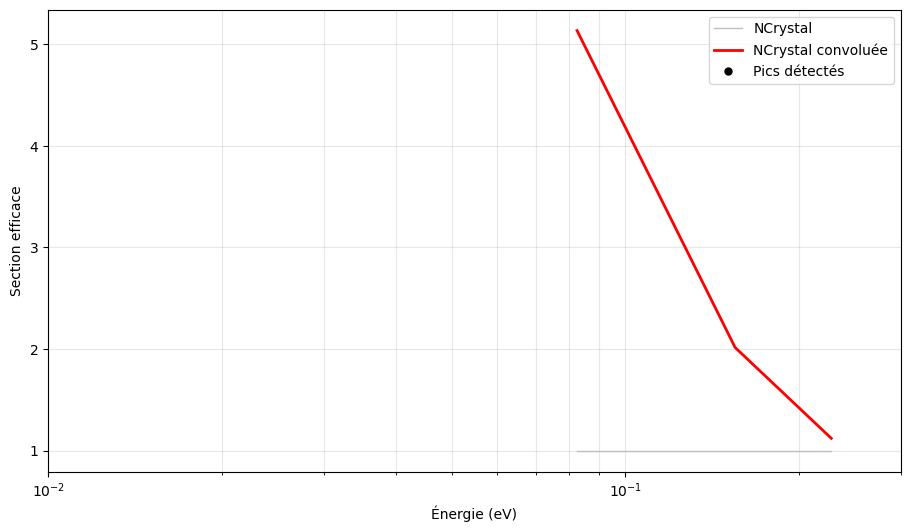

0.145
0.37273282905582134
2.5705712348677334


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================================
# Paramètres
# ==========================================================

E_MIN = 0.01
E_MAX = 0.3
f = 100

#E_nc = results["fre10"].energy.monitor.smat.x
#sigma_nc = results["fre10"].energy.monitor.smat.y
E_nc=np.linspace(E_MIN,E_MAX,5)
sigma_nc=np.ones(5)

mask = (E_nc > E_MIN) & (E_nc < E_MAX)
E_nc = E_nc[mask]
sigma_nc = sigma_nc[mask]

dE = E_nc[1] - E_nc[0]

# ==========================================================
# Convolution avec la résolution énergétique
# ==========================================================

sigma_conv = np.zeros_like(sigma_nc)

for i, Ei in enumerate(E_nc):

    # FWHM -> sigma de la gaussienne
    sigma_E = delta_E(Ei, f) / 2.355

    # Limiter le calcul à ±4 sigma
    mask_kernel = np.abs(E_nc - Ei) < 4 * sigma_E

    x = E_nc[mask_kernel]

    # Gaussienne normalisée
    kernel = np.exp(-(x - Ei)**2 / (2 * sigma_E**2))
    kernel /= np.sqrt(2 * np.pi) * sigma_E

    # Intégrale discrète
    sigma_conv[mask_kernel] += sigma_nc[i] * kernel * dE

# ==========================================================
# Détection des pics
# ==========================================================

peaks, properties = find_peaks(
    sigma_conv,
    prominence=0.002 * np.max(sigma_conv),
    distance=3
)

print("\nPics visibles :\n")

for p in peaks:
    print(f"E = {E_nc[p]:.6f} eV   sigma = {sigma_conv[p]:.4f}")

# ==========================================================
# Affichage
# ==========================================================

plt.figure(figsize=(11,6))

plt.plot(
    E_nc,
    sigma_nc,
    color="0.75",
    lw=1,
    label="NCrystal"
)

plt.plot(
    E_nc,
    sigma_conv,
    "r",
    lw=2,
    label="NCrystal convoluée"
)

plt.plot(
    E_nc[peaks],
    sigma_conv[peaks],
    "ko",
    ms=5,
    label="Pics détectés"
)

#plt.plot(results[f"fre{f}"].energy.tof.smat.x,results[f"fre{f}"].energy.tof.smat.y,lw=2, label="Simulation TOF")

plt.xscale("log")
plt.xlim(E_MIN, E_MAX)

plt.xlabel("Énergie (eV)")
plt.ylabel("Section efficace")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.show()

aire_theo = np.trapezoid(sigma_nc, E_nc)
aire_conv = np.trapezoid(sigma_conv, E_nc)

print(aire_theo)
print(aire_conv)
print(aire_conv / aire_theo)

In [1]:
# DEMI LARGEUR
FLIGHT_PATH=1.9
PULSE_WIDTH=3.5
RF_FACTOR = 145


def delta_E(E_eV, f):
    v = 13850 * np.sqrt(E_eV)
    t = FLIGHT_PATH / v
    dt = PULSE_WIDTH / (RF_FACTOR * 2 * np.pi * f)
    return E_eV * (2 * dt / t)

E = np.logspace(np.log10(0.001), np.log10(0.3), 2000)
f=100

plt.figure()
plt.errorbar(E,[delta_E(e,f) for e in E],label='delta_E') 
plt.legend()
#plt.xscale("log")
#plt.yscale("log")
plt.show()

NameError: name 'np' is not defined